# Vectorizing `VeriGym` environments

In this tutorial, we showcase how to create vectorized versions of `VeriGym` environments.
We cover the three main types of instantiable `VeriGymEnv`s: `GenerativeEnv`, `ExplicitEnv`, and `FrameworkExplicitEnv`.
There are also three ways of vectorizing environments: using `gymnasium`-native functions, using the interface from `stable_baselines3`, and using `VeriGym`-native functions.

### How can we vectorize different types of `VeriGymEnv`s?

The table below summarizes which combinations of API and `VeriGymEnv` work.

| | `gymnasium.make_vec` | `sb3.make_vec_env` | `VeriGymEnv.make_vec` | Notes |
|---|---|---|---|---|
|`GenerativeEnv.from_gymnasium` | (✅) | ✅ | ✅ | `gymnasium.make_vec` can be called with an `id`. `GenerativeEnv` is not registered in `gymnasium`. Therefore, it can only be called with the env `spec`.|
|`GenerativeEnv.from_prism`| (✅) | (✅) | (✅) | For envs that include `stormpy`  objects, only `vectorization_mode="sync"` is available due to serialization issues with C++ objects |
|`ExplicitEnv` | ✅ | ✅ | ✅ | |
| `FrameworkExplicitEnv` | (✅) | (✅) | (✅) | For envs that include `stormpy`  objects, only `vectorization_mode="sync"` is available due to serialization issues with C++ objects |

### Why do we want to vectorize?

Vectorized environments allow for parallel training on several environments at the same time - this can drastically increase the data throughput and decrease the training time.

### Why do we include custom `VeriGym`-native function?

The interfacing is often simpler with our custom types of `VeriGymEnv`s, which you can see in the later parts of this tutorial.


## Imports, Helpers, and Data

In [1]:
import warnings
warnings.filterwarnings("ignore")

from verigym.environments.generativeenv import GenerativeEnv
from verigym.environments.explicitenv import ExplicitEnv
from verigym.environments.frameworkexplicitenv import FrameworkExplicitEnv
from verigym.environments.transition_func import TransitionFunction
from verigym.environments.reward_func import RewardFunction
from verigym.frameworks.stormpy.stormpy_utils import load_stormpy_model
from verigym.frameworks.stormpy.formatter import StormpyFormatter

import gymnasium as gym
import numpy as np
from stable_baselines3.common.env_util import make_vec_env

import matplotlib.pyplot as plt

In [2]:
def print_vec_env_info(vec_env):
    print("This is the: ", vec_env)
    print("Observation space: ", vec_env.observation_space)
    print("Action space: ", vec_env.action_space)
    print("Number of envs: ", vec_env.num_envs)
    print()

In [3]:
T = TransitionFunction.from_array(
    np.array(
        [[[0.0, 0.5, 0.5], # s0, a
        [0.2, 0.8, 0.0]], # s0, b
        [[0.5, 0.5, 0.0], # s1, a
            [0.0, 0.2, 0.8]],# s1, b
            [[0.0, 0.0, 1.0],
            [0.0, 0.0, 1.0]]]
    )
)
R = RewardFunction.from_array(
    np.array(
        [[1.0, 0.0],
        [0.2, 1.0],
        [0.0, 0.0]]
    )
)
explicit_env_kwargs = {
    "nr_states": 3,
    "nr_actions": 2,
    "initial_state_distr": np.array([1.0, 0.0, 0.0]),
    "transition_function": T,
    "reward_function": R
}

## Vectorizing `GenerativeEnvs` based on `gym.Env`

We first initialize our stand-alone `gym.Env` using `"FrozenLake-v1"` as our example. 
We also create a stand-alone `GenerativeEnv` for reference.

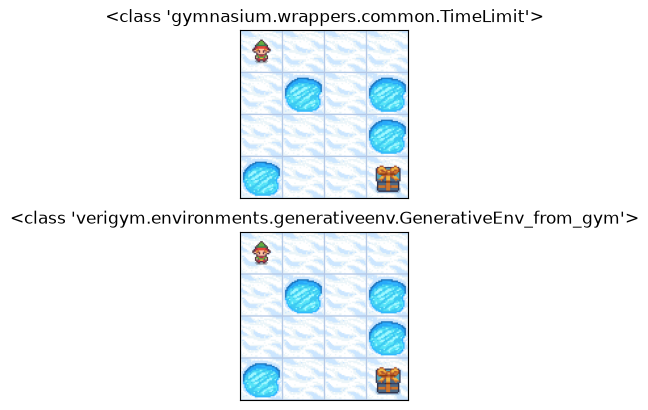

In [4]:
env = gym.make("FrozenLake-v1", is_slippery=False, render_mode="rgb_array")
gen_env = GenerativeEnv.from_gymnasium(env)

env.reset()
env_rgb = env.render()
gen_env.reset()
gen_env_rgb = gen_env.render()

fig, axs = plt.subplots(2)
axs[0].imshow(env_rgb)
axs[0].set_title(f"{type(env)}")
axs[1].imshow(gen_env_rgb)
axs[1].set_title(f"{type(gen_env)}")
for i in range(2):
    axs[i].set_xticks([])
    axs[i].set_yticks([])

plt.show()

For a standard gym environment, we have two options to vectorize (without initializing the env first): using `gym.make_vec` or `make_vec_env` from `sb3`.

In [5]:
# using gymnasium
gym_vec_env = gym.make_vec("FrozenLake-v1", is_slippery=False, render_mode="rgb_array",
                           num_envs=4)

# using stable-baselines3
sb3_vec_env = make_vec_env("FrozenLake-v1", n_envs=4, env_kwargs={"is_slippery": False, "render_mode": "rgb_array"})

Their representation differs slightly.

This is the:  SyncVectorEnv(FrozenLake-v1, num_envs=4)
Observation space:  MultiDiscrete([16 16 16 16])
Action space:  MultiDiscrete([4 4 4 4])
Number of envs:  4

This is the:  <stable_baselines3.common.vec_env.dummy_vec_env.DummyVecEnv object at 0x12e8865a0>
Observation space:  Discrete(16)
Action space:  Discrete(4)
Number of envs:  4



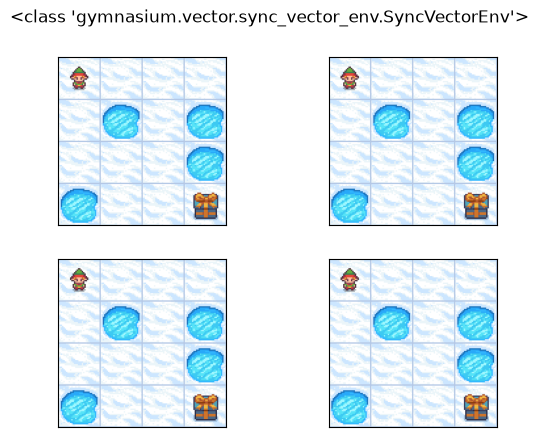

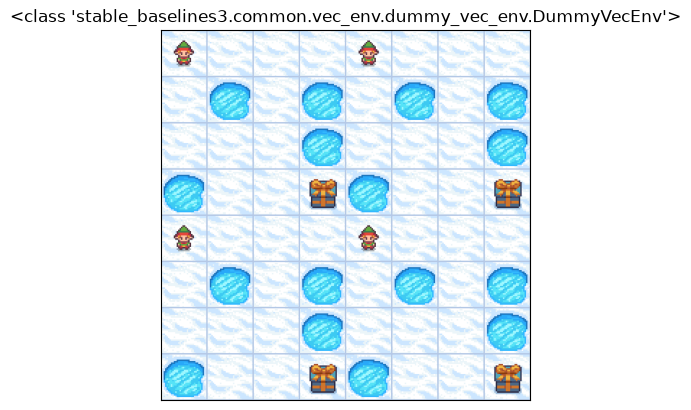

In [6]:
print_vec_env_info(gym_vec_env)
gym_vec_env.reset()
gym_vec_env_rgb = gym_vec_env.render()

print_vec_env_info(sb3_vec_env)
sb3_vec_env.reset()
sb3_vec_env_rgb = sb3_vec_env.render()

fig, axs = plt.subplots(nrows=2, ncols=2)
fig.suptitle(f"{type(gym_vec_env)}")
for i in range(4): 
    axs[i%2, int(i/2)].imshow(gym_vec_env_rgb[i])
    axs[i%2, int(i/2)].set_xticks([])
    axs[i%2, int(i/2)].set_yticks([])
plt.show()

plt.title(f"{type(sb3_vec_env)}")
plt.imshow(sb3_vec_env_rgb)
plt.xticks([])
plt.yticks([])
plt.show()

We have the same options available when using `verigym.GenerativeEnv`s that were built `from_gymnasium`. 
The calls are slightly different, though:
- For `gym.make_vec`, we do not have an `env_id` available for arbitrary `GenerativeEnvs`. Therefore, we call the function with the specs of the underlying env: `env.spec`.
- For `make_vec_caller`, we also do not have the `env_id` available. Therefore, we write a callback function `sb3_make_vec_caller`, that creates a new `GenerativeEnv` object for each of the vectorized environments.

Additionally, we can create vectorized environments using the `VeriGym` native `GenerativeEnv.vec_from_gymnasium` method.

In [7]:
gen_env_gym = gym.make_vec(gen_env.spec, num_envs=4)

def sb3_make_vec_caller():
    env = gym.make("FrozenLake-v1", is_slippery=False, render_mode="rgb_array")
    return GenerativeEnv.from_gymnasium(env)

gen_env_sb3 = make_vec_env(env_id=sb3_make_vec_caller, 
                           n_envs=4)

In [8]:
vec_gen_env = GenerativeEnv.vec_from_gymnasium(env, num_envs=4)

In [9]:
print("Using gym.make:")
print_vec_env_info(gen_env_gym)
print("Using sb3 make_vec_env:")
print_vec_env_info(gen_env_sb3)
print("Using GenerativeEnv.vec_from_gymnasium:")
print_vec_env_info(vec_gen_env)

Using gym.make:
This is the:  SyncVectorEnv(FrozenLake-v1, num_envs=4)
Observation space:  MultiDiscrete([16 16 16 16])
Action space:  MultiDiscrete([4 4 4 4])
Number of envs:  4

Using sb3 make_vec_env:
This is the:  <stable_baselines3.common.vec_env.dummy_vec_env.DummyVecEnv object at 0x12ef13260>
Observation space:  Discrete(16)
Action space:  Discrete(4)
Number of envs:  4

Using GenerativeEnv.vec_from_gymnasium:
This is the:  SyncVectorEnv(num_envs=4)
Observation space:  MultiDiscrete([16 16 16 16])
Action space:  MultiDiscrete([4 4 4 4])
Number of envs:  4



## Vectorizing `ExplicitEnvs`

We first define a small explicit MDP with 3 states and 2 actions. You can find below also a visualization.

![A drawing of the small MDP](../examples/tutorial_files/tutorial_vecenv_mdp.png)

Then, we show how to easily create vectorized environments using all three methods.

In [10]:
exp_env_vec = ExplicitEnv.make_vec(4, vectorization_mode="sync",
                                    **explicit_env_kwargs)

exp_env_gym = gym.make_vec("ExplicitEnv-v0", **explicit_env_kwargs, num_envs=4)

exp_env_sb3 = make_vec_env("ExplicitEnv-v0", env_kwargs=explicit_env_kwargs | {"render_mode": None}, n_envs=4)


print("Using gym.make_vec:")
print_vec_env_info(exp_env_gym)
print("Using sb3 make_vec_env:")
print_vec_env_info(exp_env_sb3)
print("Using ExplicitEnv.make_vec:")
print_vec_env_info(exp_env_vec)

Using gym.make_vec:
This is the:  SyncVectorEnv(ExplicitEnv-v0, num_envs=4)
Observation space:  MultiDiscrete([3 3 3 3])
Action space:  MultiDiscrete([2 2 2 2])
Number of envs:  4

Using sb3 make_vec_env:
This is the:  <stable_baselines3.common.vec_env.dummy_vec_env.DummyVecEnv object at 0x165e73d40>
Observation space:  Discrete(3)
Action space:  Discrete(2)
Number of envs:  4

Using ExplicitEnv.make_vec:
This is the:  SyncVectorEnv(num_envs=4)
Observation space:  MultiDiscrete([3 3 3 3])
Action space:  MultiDiscrete([2 2 2 2])
Number of envs:  4



## Vectorizing `FrameworkExplicitEnv`s

`FrameworkExplicitEnv`s can be built from stormpy mdps. We are using a small test MDP for this example. `test_2d` is 2D grid-world, in which some fields are deemed "unsafe" and entering them leads to loosing. Reaching the bottom right corner leads to "success". 
We are parsing the MDP from a `.prism` file (specified in the PRISM modelling language), and then load the MDP using `stormpy`.
We first look at the MDP:

In [11]:
prism_file = "../tests/test_2d.prism"
mdp = load_stormpy_model(prism_file)

print(mdp)

-------------------------------------------------------------- 
Model type: 	MDP (sparse)
States: 	25
Transitions: 	154
Choices: 	88
Reward Models:  reward
State Labels: 	4 labels
   * init -> 1 item(s)
   * deadlock -> 4 item(s)
   * unsafe -> 3 item(s)
   * success -> 1 item(s)
Choice Labels: 	4 labels
   * UP -> 21 item(s)
   * DOWN -> 21 item(s)
   * LEFT -> 21 item(s)
   * RIGHT -> 21 item(s)
-------------------------------------------------------------- 



Here again we have the three options for vectorizing this environment type:

In [12]:
fe_env_gym = gym.make_vec("FrameworkExplicitEnv-v0", 
                          model=mdp, 
                          formatter=StormpyFormatter(mdp),
                          num_envs=4)

fe_env_sb3 = make_vec_env(env_id="FrameworkExplicitEnv-v0",
                          env_kwargs={"model": mdp, "formatter": StormpyFormatter(mdp),
                                      "render_mode": None}, 
                           n_envs=4)

fe_env_vec = FrameworkExplicitEnv.vec_from_stormpy(mdp, num_envs = 4, vectorization_mode="sync")

print("Using gym.make_vec:")
print_vec_env_info(fe_env_gym)
print("Using sb3 make_vec_env:")
print_vec_env_info(fe_env_sb3)
print("Using FrameworkExplicitEnv.vec_from_stormpy:")
print_vec_env_info(fe_env_vec)


Using gym.make_vec:
This is the:  SyncVectorEnv(FrameworkExplicitEnv-v0, num_envs=4)
Observation space:  MultiDiscrete([25 25 25 25])
Action space:  MultiDiscrete([4 4 4 4])
Number of envs:  4

Using sb3 make_vec_env:
This is the:  <stable_baselines3.common.vec_env.dummy_vec_env.DummyVecEnv object at 0x165ebd1c0>
Observation space:  Discrete(25)
Action space:  Discrete(4)
Number of envs:  4

Using FrameworkExplicitEnv.vec_from_stormpy:
This is the:  SyncVectorEnv(num_envs=4)
Observation space:  MultiDiscrete([25 25 25 25])
Action space:  MultiDiscrete([4 4 4 4])
Number of envs:  4

